## **Forward Propagation from Scratch**

### **Objective**

The goal of this notebook is to understand how a neural network performs **forward propagation** without using TensorFlow or PyTorch

Every computation will be implemented manually using **NumPy**

Instead of treating a neural network as a black box, we will visualize every important step including:

- Input Image
- Pixels
- Weights
- Bias
- Hidden Layer
- Activation
- Output Prediction

By the end of this notebook, we will understand exactly how information flows inside a neural network

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

plt.style.use("dark_background")
sns.set_theme(style="white")

np.random.seed(42)

### **Why do we use `np.random.seed(42)`?**

- Neural networks initialize weights randomly.
- Fixing the random seed ensures that every time this notebook is executed, the same random weights are generated
- This makes our experiments reproducible

### **Create a Toy Image**

- Instead of using a real dataset, we will begin with a small grayscale image
- A small image allows us to manually observe every pixel and understand how the neural network processes visual information

In [2]:
image = np.array([
    [20, 30, 40, 20],
    [50, 220, 230, 40],
    [40, 210, 240, 30],
    [20, 30, 20, 10]
])

print(image)

[[ 20  30  40  20]
 [ 50 220 230  40]
 [ 40 210 240  30]
 [ 20  30  20  10]]


### **Visualizing the Input Image**

- Although this image is simply a matrix of numbers, a computer interprets it as pixel intensities
- Higher values correspond to brighter pixels

**`Let's visualize it`**

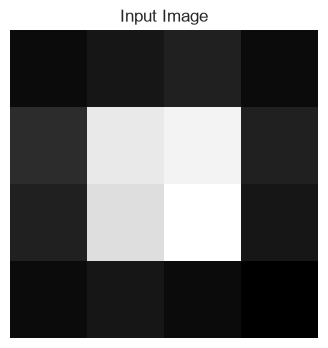

In [3]:
plt.figure(figsize=(4,4))

plt.imshow(image, cmap="gray")

plt.title("Input Image")

plt.axis("off")

plt.show()

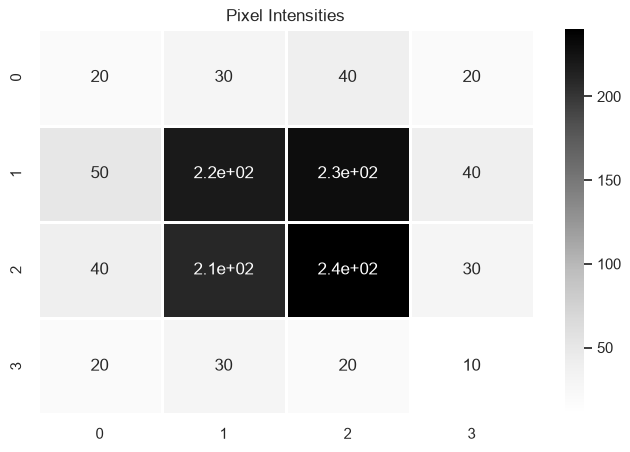

In [4]:
plt.figure(figsize=(8,5))

sns.heatmap(
    image,
    annot=True,
    cmap="Greys",
    cbar=True,
    linewidths=1
)

plt.title("Pixel Intensities")

plt.show()

### **Deep Learning Insight**

A neural network does not `"see" an image the way humans do`

For a neural network, an image is simply a collection of numerical pixel values

The task of the network is to learn meaningful patterns from these numbers

### **Step 2: Flatten the Image**

A neural network cannot directly process a 2D image

Instead, the image is converted into a **1D feature vector**

This process is called **Flattening**

Our 4×4 image contains:

- 4 Rows
- 4 Columns

Total Features:

4 × 4 = **16 Pixels**

Each pixel becomes one input neuron in the neural network

In [5]:
# Flatten the image

image_flat = image.flatten()

print("Shape:", image_flat.shape)

print(image_flat)

Shape: (16,)
[ 20  30  40  20  50 220 230  40  40 210 240  30  20  30  20  10]




The neural network does not know that these values came from an image.

For the network, they are simply **16 numerical features**.

Each feature will become one input neuron.

### **visualizing the Flattened Image**

Let's compare the original image with its flattened representation

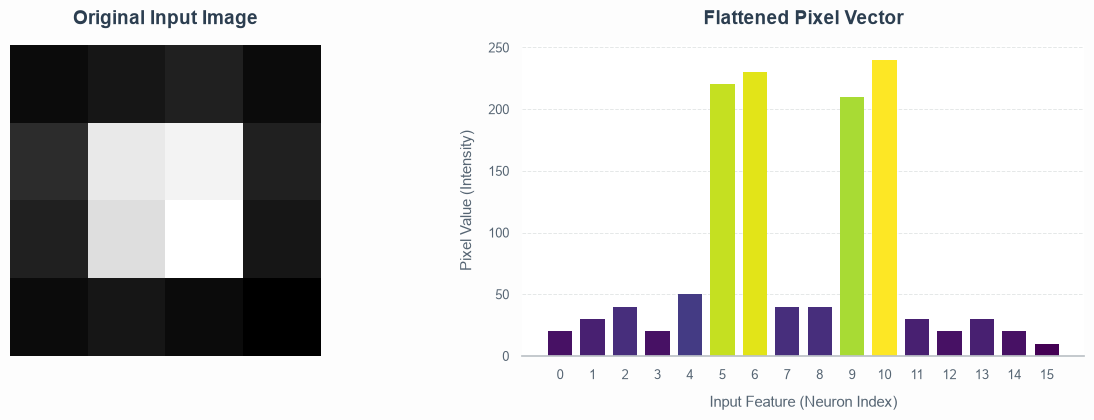

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'

# Figure setup with better dimensions and crisp resolution (DPI)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100, facecolor='#fdfdfd')

# --- 1. Original Image Plot ---
axes[0].imshow(image, cmap="gray", interpolation='nearest')
axes[0].set_title("Original Input Image", fontsize=14, fontweight='bold', pad=15)
axes[0].axis("off")

# --- 2. Flattened Vector Bar Chart ---

norms = plt.Normalize(min(image_flat), max(image_flat))
colors = plt.cm.viridis(norms(image_flat))  


x_range = range(len(image_flat))
bars = axes[1].bar(x_range, image_flat, color=colors, width=0.75, edgecolor='none')


axes[1].set_title("Flattened Pixel Vector", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Input Feature (Neuron Index)", fontsize=11, labelpad=10, color='#566573')
axes[1].set_ylabel("Pixel Value (Intensity)", fontsize=11, labelpad=10, color='#566573')


axes[1].set_xticks(x_range)
axes[1].tick_params(axis='both', colors='#566573', labelsize=9)

# Soft structural grid behind the bars
axes[1].set_axisbelow(True)
axes[1].yaxis.grid(True, color='#E5E8E8', linestyle='--', linewidth=0.7)


for spine in ['top', 'right', 'left']:
    axes[1].spines[spine].set_visible(False)
axes[1].spines['bottom'].set_color('#BDC3C7') 

# Final layout management to prevent cropping
plt.tight_layout(pad=3.0)
plt.show()


### **Creating the Input Layer**

Each pixel of the flattened image becomes one neuron in the input layer

Since our image contains **16 pixels**, the input layer will contain **16 neurons**

In [7]:
num_inputs = len(image_flat)

print("Number of Input Neurons:",num_inputs)

Number of Input Neurons: 16


In [8]:

image_flat = [0.1, 0.5, 0.9, 0.2, 0.0, 0.8, 0.4, 0.3, 0.7, 0.6, 0.2, 0.1, 0.9, 0.5, 0.0, 0.4]

fig = go.Figure()

x_positions = [0] * 16
y_positions = list(range(15, -1, -1))

text_labels = [f"<b>{val:.1f}</b>" if isinstance(val, float) else f"<b>{str(val)}</b>" for val in image_flat]
hover_texts = [
    f"<b>Input Neuron {i+1}</b><br>Pixel Value: {val}<extra></extra>"
    for i, val in enumerate(image_flat)
]

fig.add_trace(
    go.Scatter(
        x=x_positions,
        y=y_positions,
        mode="markers+text",
        marker=dict(
            size=42,
            color=image_flat,
            colorscale="Plasma",
            showscale=False,
            cmin=0.0,
            cmax=1.0,
            line=dict(width=1.5, color="#1e293b")
        ),
        text=text_labels,
        textposition="middle center",
        textfont=dict(
            color="white",
            size=11,
            family="Arial"
        ),
        hoverinfo="text",
        hovertext=hover_texts
    )
)

fig.update_layout(
    title=dict(
        text="<b>Input Layer (16 Neurons)</b>",
        font=dict(color="#1e293b", size=16, family="Arial"),
        x=0.5,
        y=0.98
    ),
    xaxis=dict(visible=False, range=[-0.6, 0.6]),
    yaxis=dict(visible=False, range=[-1, 16]),
    width=360,
    height=950,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=10, r=10, t=50, b=10),
    showlegend=False  
)

fig.show(renderer="notebook_connected")


### **Building the First Hidden Neuron**

A neuron receives information from **every input neuron**

Each connection has its own **weight**

Initially, these weights are assigned randomly

In [9]:
weights = np.random.randn(16)

bias = np.random.randn()

print("Weights Shape:",weights.shape)

print("Bias:",bias)

Weights Shape: (16,)
Bias: -1.0128311203344238


### **Visualizing the Initial Weights**

Weights determine the importance of each pixel

Positive weights increase the neuron's activation

Negative weights suppress the neuron's activation

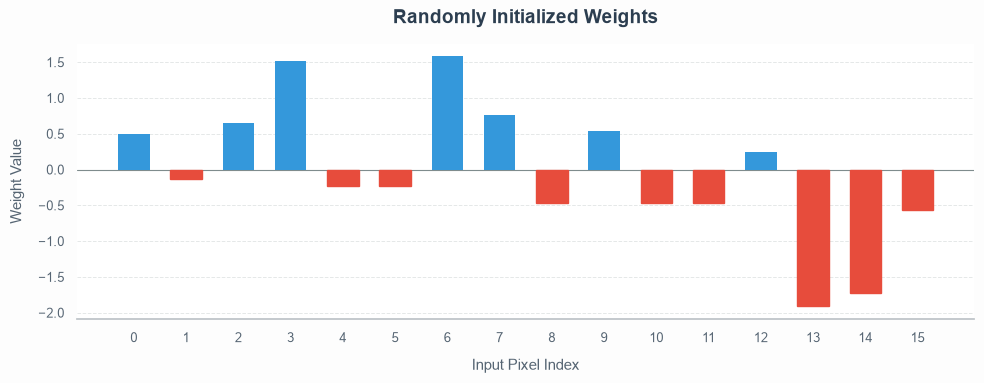

In [10]:


plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 4), dpi=100, facecolor='#fdfdfd')

x_range = range(16)
bars = ax.bar(x_range, weights, width=0.6, color='#3498db', edgecolor='none', zorder=3)

for bar in bars:
    if bar.get_height() < 0:
        bar.set_color('#e74c3c')

ax.set_title("Randomly Initialized Weights", fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
ax.set_xlabel("Input Pixel Index", fontsize=11, labelpad=10, color='#566573')
ax.set_ylabel("Weight Value", fontsize=11, labelpad=10, color='#566573')

ax.set_xticks(x_range)
ax.tick_params(axis='both', colors='#566573', labelsize=9)

ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#e5e8e8', linestyle='--', linewidth=0.7)
ax.axhline(0, color='#7f8c8d', linestyle='-', linewidth=0.8, zorder=2)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#bdc3c7')

plt.tight_layout()
plt.show()


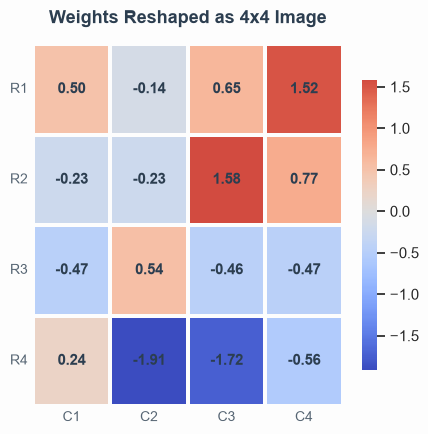

In [11]:

plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=100, facecolor='#fdfdfd')

weight_image = weights.reshape(4, 4)

sns.heatmap(
    weight_image,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1.5,
    linecolor='#fdfdfd',
    cbar=True,
    cbar_kws={"shrink": 0.8, "pad": 0.05},
    annot_kws={"size": 11, "weight": "bold", "color": "#2c3e50"},
    ax=ax
)

ax.set_title("Weights Reshaped as 4x4 Image", fontsize=13, fontweight='bold', pad=15, color='#2c3e50')

ax.tick_params(axis='both', which='both', length=0, labelsize=10, colors='#566573')
ax.set_xticklabels(['C1', 'C2', 'C3', 'C4'])
ax.set_yticklabels(['R1', 'R2', 'R3', 'R4'], rotation=0)

plt.tight_layout()
plt.show()


In [12]:


fig = go.Figure()

x_inputs = [0] * 16
y_inputs = list(range(15, -1, -1))

hover_inputs = [
    f"<b>Pixel {i+1}</b><br>Value: {image_flat[i]:.2f}<extra></extra>"
    for i in range(16)
]

for y in y_inputs:
    fig.add_shape(
        type="line",
        x0=0, y0=y, x1=3, y1=7.5,
        line=dict(color="rgba(148, 163, 184, 0.25)", width=1),
        layer="below"
    )

fig.add_trace(go.Scatter(
    x=x_inputs,
    y=y_inputs,
    mode="markers",
    marker=dict(
        size=26,
        color=image_flat,
        colorscale="Blues",
        showscale=False,
        line=dict(width=1.5, color="rgba(255, 255, 255, 0.8)")
    ),
    hoverinfo="text",
    hovertext=hover_inputs,
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[3],
    y=[7.5],
    mode="markers+text",
    marker=dict(
        size=50, 
        color="#e74c3c",
        line=dict(width=2.5, color="white")
    ),
    text=["<b>H1</b>"],
    textposition="middle center",
    textfont=dict(size=12, color="white", family="Arial"),
    hovertemplate="<b>Hidden Neuron 1</b><extra></extra>",
    showlegend=False
))

fig.update_layout(
    title=dict(
        text="<b>Input Layer Connected to First Hidden Neuron</b>",
        font=dict(size=15, color="white", family="Arial"),
        x=0.5,
        y=0.96
    ),
    xaxis=dict(visible=False, range=[-0.5, 3.5]),
    yaxis=dict(visible=False, range=[-1, 16]),
    width=550,
    height=650,
    plot_bgcolor="rgba(15, 23, 42, 1)",
    paper_bgcolor="rgba(15, 23, 42, 1)",
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show(renderer="notebook_connected")


### **Step 3: Forward Propagation**

A neuron does not process the entire image at once

Instead, it receives every pixel value through its corresponding weight

Each input contributes differently to the neuron's final decision

The computation performed by a neuron is:

\[
Z = W^T X + b
\]

where

- **X** -> Input Feature Vector
- **W** -> Weight Vector
- **b** -> Bias
- **Z** -> Weighted Sum

The weighted sum is then passed through an activation function

### **Input Features and Their Corresponding Weights**

Before computing the weighted sum, let's observe every pixel and its assigned weight

In [13]:
import pandas as pd

feature_table = pd.DataFrame({

    "Input Neuron": np.arange(1,17),

    "Pixel Value": image_flat,

    "Weight": np.round(weights,3)

})

feature_table

,Input Neuron,Pixel Value,Weight
0,1,0.1,0.497
1,2,0.5,-0.138
2,3,0.9,0.648
3,4,0.2,1.523
4,5,0.0,-0.234
5,6,0.8,-0.234
6,7,0.4,1.579
7,8,0.3,0.767
8,9,0.7,-0.469
9,10,0.6,0.543


### **Pixel-wise Contribution**

Each pixel contributes independently

Contribution = Pixel × Weight

Instead of using `np.dot()` immediately, we calculate every contribution manually to understand the mathematics behind forward propagation

In [14]:
contributions = image_flat * weights

feature_table["Contribution"] = np.round(contributions,2)

feature_table

,Input Neuron,Pixel Value,Weight,Contribution
0,1,0.1,0.497,0.05
1,2,0.5,-0.138,-0.07
2,3,0.9,0.648,0.58
3,4,0.2,1.523,0.30
4,5,0.0,-0.234,-0.00
5,6,0.8,-0.234,-0.19
6,7,0.4,1.579,0.63
7,8,0.3,0.767,0.23
8,9,0.7,-0.469,-0.33
9,10,0.6,0.543,0.33


### **What is a Contribution?**

A contribution tells us how much a single input pixel influences the hidden neuron

- Large positive value -> Strong positive influence
- Large negative value -> Strong negative influence
- Value near zero -> Almost no influence

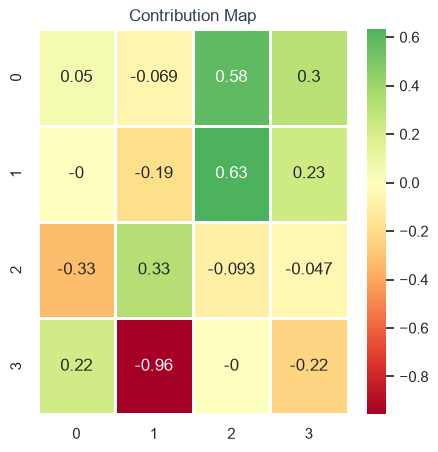

In [15]:
plt.figure(figsize=(5,5))

sns.heatmap(

    contributions.reshape(4,4),

    annot=True,

    cmap="RdYlGn",

    center=0,

    linewidths=1

)

plt.title("Contribution Map")

plt.show()


# Interpretation
#Green: Neuron likes this pixel
#Red: Neuron suppresses this pixel

### **Computing the Weighted Sum**

Now we combine all pixel contributions.

The weighted sum is simply the sum of all individual contributions.

\[
Z=\sum_{i=1}^{16}(x_iw_i)
\]

In [16]:
weighted_sum = np.sum(contributions)

print("Weighted Sum =",weighted_sum)

Weighted Sum = 0.43652925213898086


### **Adding Bias**

The weighted sum alone is not enough

A neuron also learns a **bias**, which shifts the decision boundary

Without bias, every neuron would always be constrained to pass through the origin


In [17]:
print("Weighted Sum :",weighted_sum)

print("Bias :",bias)

z = weighted_sum + bias

print("Final Z :",z)

Weighted Sum : 0.43652925213898086
Bias : -1.0128311203344238
Final Z : -0.5763018681954429


In [18]:
for i in range(len(image_flat)):
    print(
        f"Pixel {i+1:2d}: "
        f"{image_flat[i]:5.2f}"
        f" × "
        f"{weights[i]:7.3f}"
        f" = "
        f"{contributions[i]:8.2f}"
    )

print("\n--------------------------------")
print("Weighted Sum =", weighted_sum)
print("Bias =", bias)
print("--------------------------------")
print("Final Z =", z)


Pixel  1:  0.10 ×   0.497 =     0.05
Pixel  2:  0.50 ×  -0.138 =    -0.07
Pixel  3:  0.90 ×   0.648 =     0.58
Pixel  4:  0.20 ×   1.523 =     0.30
Pixel  5:  0.00 ×  -0.234 =    -0.00
Pixel  6:  0.80 ×  -0.234 =    -0.19
Pixel  7:  0.40 ×   1.579 =     0.63
Pixel  8:  0.30 ×   0.767 =     0.23
Pixel  9:  0.70 ×  -0.469 =    -0.33
Pixel 10:  0.60 ×   0.543 =     0.33
Pixel 11:  0.20 ×  -0.463 =    -0.09
Pixel 12:  0.10 ×  -0.466 =    -0.05
Pixel 13:  0.90 ×   0.242 =     0.22
Pixel 14:  0.50 ×  -1.913 =    -0.96
Pixel 15:  0.00 ×  -1.725 =    -0.00
Pixel 16:  0.40 ×  -0.562 =    -0.22

--------------------------------
Weighted Sum = 0.43652925213898086
Bias = -1.0128311203344238
--------------------------------
Final Z = -0.5763018681954429


In [19]:
import plotly.graph_objects as go

fig = go.Figure()

x_inputs = [0] * 16
y_inputs = list(range(15, -1, -1))

hover_inputs = [
    f"<b>Input {i+1}</b><br>Pixel: {image_flat[i]:.2f}<br>Weight: {weights[i]:.3f}<br>Contribution: {contributions[i]:.2f}<extra></extra>"
    for i in range(16)
]

for i, y in enumerate(y_inputs):
    w_color = "rgba(46, 204, 113, 0.45)" if contributions[i] >= 0 else "rgba(231, 76, 60, 0.45)"
    w_thickness = max(0.8, min(abs(contributions[i]) * 1.5, 5))
    
    fig.add_shape(
        type="line",
        x0=0, y0=y, x1=3, y1=7.5,
        line=dict(color=w_color, width=w_thickness),
        layer="below"
    )

fig.add_trace(go.Scatter(
    x=x_inputs,
    y=y_inputs,
    mode="markers",
    marker=dict(
        size=26,
        color=image_flat,
        colorscale="Blues",
        showscale=False,
        line=dict(width=1.5, color="rgba(255, 255, 255, 0.8)")
    ),
    hoverinfo="text",
    hovertext=hover_inputs,
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[3],
    y=[7.5],
    mode="markers+text",
    marker=dict(
        size=46, 
        color="#e74c3c",
        line=dict(width=2.5, color="white")
    ),
    text=[f"<b>Z={z:.2f}</b>"],
    textposition="middle center",
    textfont=dict(size=11, color="white", family="Arial"),
    hovertemplate=f"<b>Hidden Neuron</b><br>Net Input (Z): {z:.4f}<extra></extra>",
    showlegend=False
))

fig.update_layout(
    title=dict(
        text="<b>Forward Propagation Pipeline</b>",
        font=dict(size=16, color="white", family="Arial"),
        x=0.5,
        y=0.96
    ),
    xaxis=dict(visible=False, range=[-0.5, 3.5]),
    yaxis=dict(visible=False, range=[-1, 16]),
    width=550,
    height=650,
    plot_bgcolor="rgba(15, 23, 42, 1)",
    paper_bgcolor="rgba(15, 23, 42, 1)",
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show(renderer="notebook_connected")


### Creating the Hidden Layer

Instead of using a single neuron, we now create a hidden layer containing **4 neurons**.

Each hidden neuron receives all **16 input features**.

This means:

- Input Features = 16
- Hidden Neurons = 4

The weight matrix has shape:

(16 × 4)

In [20]:
input_size = 16
hidden_size = 4

W1 = np.random.randn(input_size, hidden_size)

b1 = np.random.randn(hidden_size)

print("Weight Matrix Shape :", W1.shape)
print("Bias Vector Shape   :", b1.shape)

Weight Matrix Shape : (16, 4)
Bias Vector Shape   : (4,)


### **Forward Propagation**

The hidden layer receives all input features simultaneously.

The mathematical equation is

Z₁ = XW₁ + b₁

where

- X -> Input Vector
- W₁ -> Weight Matrix
- b₁ -> Bias Vector

In [21]:
Z1 = image_flat @ W1 + b1

print("Hidden Layer Output (Z1):")

print(np.round(Z1,2))

Hidden Layer Output (Z1):
[-1.57 -0.03  0.93 -2.15]


### **ReLU Activation**

A neuron should only activate when useful information is detected.

ReLU removes all negative values.

ReLU(x)

= max(0,x)

In [22]:
A1 = np.maximum(0,Z1)

print(A1)

[0.         0.         0.93276251 0.        ]


### **Why ReLU?**

Negative values are treated as inactive neurons

Positive values are allowed to continue through the network

This makes the network capable of learning complex patterns

## **Output Layer**

The activated hidden neurons become the input for the output layer

We create

- Hidden Neurons = 4
- Output Neurons = 3

Weight Matrix Shape

(4 × 3)

In [23]:
output_size = 3

W2 = np.random.randn(hidden_size,output_size)

b2 = np.random.randn(output_size)

In [24]:
Z2 = A1 @ W2 + b2

print(np.round(Z2,2))

[ 1.16 -0.65 -0.54]


### **Softmax Activation**

Softmax converts raw scores into probabilities

The probabilities always sum to 1

In [25]:
exp_scores = np.exp(Z2 - np.max(Z2))

probabilities = exp_scores / np.sum(exp_scores)

print(np.round(probabilities,4))

[0.7436 0.1212 0.1352]


In [26]:
prediction = np.argmax(probabilities)

print(f"Predicted Class : {prediction+1}")

Predicted Class : 1


In [27]:
i
fig = go.Figure()

input_y = np.linspace(0, 15, 16)
hidden_y = np.linspace(3, 12, 4)
output_y = np.linspace(5, 10, 3)

for iy in input_y:
    for hy in hidden_y:
        fig.add_shape(
            type="line",
            x0=0, y0=iy, x1=4, y1=hy,
            line=dict(color="rgba(203, 213, 225, 0.4)", width=0.8),
            layer="below"
        )

for hy in hidden_y:
    for oy in output_y:
        fig.add_shape(
            type="line",
            x0=4, y0=hy, x1=8, y1=oy,
            line=dict(color="rgba(148, 163, 184, 0.5)", width=1.2),
            layer="below"
        )

fig.add_trace(go.Scatter(
    x=[0] * 16,
    y=input_y,
    mode="markers",
    marker=dict(
        size=22,
        color="#3b82f6",
        line=dict(width=1.5, color="white")
    ),
    hovertemplate="Input Layer Node<extra></extra>",
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[4] * 4,
    y=hidden_y,
    mode="markers+text",
    marker=dict(
        size=32,
        color="#f43f5e",
        line=dict(width=2, color="white")
    ),
    text=[f"<b>H{i+1}</b>" for i in range(4)],
    textposition="middle center",
    textfont=dict(size=10, color="white", family="Arial"),
    hovertemplate="Hidden Layer Node<extra></extra>",
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[8] * 3,
    y=output_y,
    mode="markers+text",
    marker=dict(
        size=38,
        color="#10b981",
        line=dict(width=2, color="white")
    ),
    text=[f"<b>O{i+1}</b>" for i in range(3)],
    textposition="middle center",
    textfont=dict(size=11, color="white", family="Arial"),
    hovertemplate="Output Layer Node<extra></extra>",
    showlegend=False
))

fig.update_layout(
    title=dict(
        text="<b>Complete Neural Network Architecture</b>",
        font=dict(size=18, color="#1e293b", family="Arial"),
        x=0.5,
        y=0.96
    ),
    xaxis=dict(visible=False, range=[-1, 9]),
    yaxis=dict(visible=False, range=[-1, 16]),
    width=800,
    height=550,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show(renderer="notebook_connected")
